<div style="
    background: #111827;
    color: white;
    padding: 35px;
    border-radius: 12px;
    margin-bottom: 25px;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
    font-family: Arial, sans-serif;
">

   <h1 style="
        margin: 0;
        font-size: 2.5rem;
        text-align: center;
        text-transform:uppercase;
   ">
        Clusterização de Clientes de Cartão de Crédito com K-Means
   </h1>

   <hr style="
        border: none;
        height: 1px;
        background: rgba(255,255,255,0.2);
        margin: 25px 0 10px 0;
   ">
   <div style="
        display: flex;
        flex-direction:column;
        justify-content:center;
        align-items: center;
        flex-wrap: wrap;
        gap: 15px;
        font-size: .9rem;
        color: #94a3b8;
   ">
       <p style="font-weight: 500; font-size:1.2rem; line-height: 1.5; letter-spacing:2px; margin-bottom:-.5rem;">
            Autor: <strong style="color: white; font-weight: 600;">Wellington M. Santos</strong>
       </p>
       <div style="display: flex; gap: 30px; font-weight: 500; justify-content:center">
            <a href="https://www.linkedin.com/in/wellington-moreira-santos"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               LinkedIn
            </a>
            <a href="mailto:wsantos08@hotmail.com"
               style="color:#93c5fd; text-decoration:none;">
               Contato
            </a>
            <a href="https://github.com/esscova"
               target="_blank"
               style="color:#93c5fd; text-decoration:none;">
               GitHub
            </a>
       </div>
   </div>

</div>

Neste projeto investigo o comportamento de clientes de uma operadora de cartão de crédito a partir do uso que fazem do produto, sem contar com nenhum rótulo prévio que já diga a que grupo cada cliente pertence. Diferente de um problema de classificação, em que já saberia categorias como risco baixo, médio ou alto, aqui parto de um conjunto de atributos de uso (saldo, compras, saques, limite, frequência de pagamento) e busco encontrar agrupamentos naturais que revelem perfis distintos de comportamento.

Utilizo o algoritmo K-Means por ser o método de clusterização mais difundido e por servir como base sólida de comparação para técnicas mais avançadas. O dataset escolhido é amplamente utilizado em estudos de segmentação de clientes de cartão de crédito, contendo cerca de nove mil registros e dezoito atributos de uso. Como não existe um rótulo verdadeiro para validar o resultado, dedico boa parte do notebook à validação do agrupamento usando métricas específicas de clusterização, e não a métricas de erro como em um modelo supervisionado.

As principais ferramentas empregadas são `pandas` para manipulação dos dados, `scikit-learn` para padronização, treinamento do K-Means, redução de dimensionalidade com PCA e cálculo das métricas de validação, além de `matplotlib` e `seaborn` para as visualizações.

O notebook está organizado nas seguintes seções:

1. Imports e Configurações
2. Coleta e Inspeção dos Dados
3. Análise Exploratória
4. Tratamento e Limpeza dos Dados
5. Preparação para o Modelo
6. Treinamento do Modelo
7. Avaliação do Modelo
8. Interpretação dos Clusters
9. Conclusão e Considerações Finais
10. Referências

---

## 1. Imports e Configurações

In [1]:
import session_info
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn import metrics

session_info.show(dependencies=False)

In [2]:
plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#94a3b8',
    'ytick.color':      '#94a3b8',
    'text.color':       '#f1f5f9',
    'grid.color':       '#334155',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
})

---

## 2. Coleta e Inspeção dos Dados

### 2.1 Sobre o Dataset
Com origem no Kaggle, publicado por Arjun Bhasin (`arjunbhasin2013/ccdata`). É um dos datasets mais usados em exercícios de segmentação não supervisionada, exatamente por reunir atributos de comportamento sem nenhum rótulo de grupo.

Cada linha é um titular de cartão de crédito, com o comportamento de uso resumido ao longo de um período de referência de 6 meses. Não é uma foto de um único mês, é um agregado.

O dataset possui 8950 clientes, 18 colunas (1 identificador + 17 atributos de uso).

**Dicionário de atributos**

| Atributo | O que representa |
|---|---|
| `CUST_ID` | Identificador do cliente (categórico, não entra na clusterização) |
| `BALANCE` | Saldo disponível na conta para novas compras |
| `BALANCE_FREQUENCY` | Frequência de atualização do saldo, de 0 a 1 |
| `PURCHASES` | Valor total de compras feitas |
| `ONEOFF_PURCHASES` | Valor da maior compra feita de uma vez só (à vista) |
| `INSTALLMENTS_PURCHASES` | Valor de compras feitas parceladas |
| `CASH_ADVANCE` | Valor total sacado como adiantamento em dinheiro |
| `PURCHASES_FREQUENCY` | Frequência com que o cliente faz compras, de 0 a 1 |
| `ONEOFF_PURCHASES_FREQUENCY` | Frequência de compras à vista, de 0 a 1 |
| `PURCHASES_INSTALLMENTS_FREQUENCY` | Frequência de compras parceladas, de 0 a 1 |
| `CASH_ADVANCE_FREQUENCY` | Frequência de uso do saque, de 0 a 1 |
| `CASH_ADVANCE_TRX` | Número de transações de saque |
| `PURCHASES_TRX` | Número de transações de compra |
| `CREDIT_LIMIT` | Limite de crédito do cartão |
| `PAYMENTS` | Valor total pago pelo cliente |
| `MINIMUM_PAYMENTS` | Valor mínimo pago pelo cliente |
| `PRC_FULL_PAYMENT` | Percentual de vezes que o cliente pagou a fatura integralmente |
| `TENURE` | Tempo de contrato do cartão, em meses |

### 2.2 Carregamento dos Dados

Carrego o dataset diretamente do repositório público que hospeda uma cópia do arquivo original do Kaggle, evitando a necessidade de autenticação para o download.

In [19]:
url = "https://raw.githubusercontent.com/alura-cursos/alura-clustering-validation/refs/heads/base-de-dados/CC%20GENERAL.csv"
df = pd.read_csv(url)

df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### 2.3 Visão Geral do Dataframe

In [5]:
# dimensões
df.shape

(8950, 18)

In [6]:
# tipos de dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [7]:
# dados ausentes
df.isna().sum()

CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64

In [9]:
# estatisticas descritivas
df.describe().T

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.474828,2081.531879,0.000000,128.281915,873.385231,2054.140036,19043.13856
BALANCE_FREQUENCY,8950.0,0.877271,0.236904,0.000000,0.888889,1.000000,1.000000,1.00000
PURCHASES,8950.0,1003.204834,2136.634782,0.000000,39.635000,361.280000,1110.130000,49039.57000
ONEOFF_PURCHASES,8950.0,592.437371,1659.887917,0.000000,0.000000,38.000000,577.405000,40761.25000
INSTALLMENTS_PURCHASES,8950.0,411.067645,904.338115,0.000000,0.000000,89.000000,468.637500,22500.00000
CASH_ADVANCE,8950.0,978.871112,2097.163877,0.000000,0.000000,0.000000,1113.821139,47137.21176
PURCHASES_FREQUENCY,8950.0,0.490351,0.401371,0.000000,0.083333,0.500000,0.916667,1.00000
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.202458,0.298336,0.000000,0.000000,0.083333,0.300000,1.00000
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.364437,0.397448,0.000000,0.000000,0.166667,0.750000,1.00000
CASH_ADVANCE_FREQUENCY,8950.0,0.135144,0.200121,0.000000,0.000000,0.000000,0.222222,1.50000


In [10]:
# estatisticas descritivas de dados monetários
df[['BALANCE', 'PURCHASES', 'CASH_ADVANCE']].describe()

,BALANCE,PURCHASES,CASH_ADVANCE
count,8950.000000,8950.000000,8950.000000
mean,1564.474828,1003.204834,978.871112
std,2081.531879,2136.634782,2097.163877
min,0.000000,0.000000,0.000000
25%,128.281915,39.635000,0.000000
50%,873.385231,361.280000,0.000000
75%,2054.140036,1110.130000,1113.821139
max,19043.138560,49039.570000,47137.211760


### 2.4 Resumo Inicial dos Dados
Nesta fase é visto que a base é coerente com as informações fornecidas no Kaggle, logo:
>O Dataset contém 8950 registros de clientes e 18 atributos, incluindo o identificador `CUST_ID`.
>
>Os atributos numéricos já estão nos tipos corretos (`float64` ou `int64`), sem necessidade de conversão. `CUST_ID` é do tipo string e não entra nas etapas de clusterização. 
>
>`CREDIT_LIMIT` tem 1 registro com dado ausente, e `MINIMUM_PAYMENTS` tem 313.
>
>As três variáveis monetárias apresentam assimetria positiva, com média maior que a mediana. Em `CASH_ADVANCE` essa assimetria é mais extrema, já que a mediana é zero, indicando que pelo menos metade dos clientes nunca realizou saque no cartão. O salto do terceiro quartil (1113,82) até o valor máximo (47137,21) reforça que o uso de saque está concentrado em uma pequena parcela dos clientes.

---

## 3. Análise Exploratória

### 3.1 Atributos Constantes

Antes de seguir, verifico se algum atributo carrega o mesmo valor para todos os clientes, o que o tornaria inútil para diferenciar comportamentos. O atributo `TENURE` representa o tempo de contrato do cartão e é candidato a essa situação, já que a base costuma concentrar clientes com o mesmo período de permanência.

In [11]:
df['TENURE'].value_counts()

TENURE
12    7584
11     365
10     236
6      204
8      196
7      190
9      175
Name: count, dtype: int64

In [12]:
df['TENURE'].value_counts(normalize=True)

TENURE
12    0.847374
11    0.040782
10    0.026369
6     0.022793
8     0.021899
7     0.021229
9     0.019553
Name: proportion, dtype: float64

>`TENURE` concentra 84,7% dos clientes no valor 12, e 91,4% na faixa de 10 a 12 meses. Com apenas seis valores distintos e essa concentração, o atributo carrega pouca variância para diferenciar clientes, o que confirma a decisão de removê-lo.

### 3.2 Correlação entre Atributos
Observo a correlação entre os atributos numéricos para entender a redundância de informação na base. Atributos de compra (`PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`) tendem a ser correlacionados entre si por construção, o que já sinaliza que uma redução de dimensionalidade mais adiante pode capturar boa parte da variância em poucos componentes.

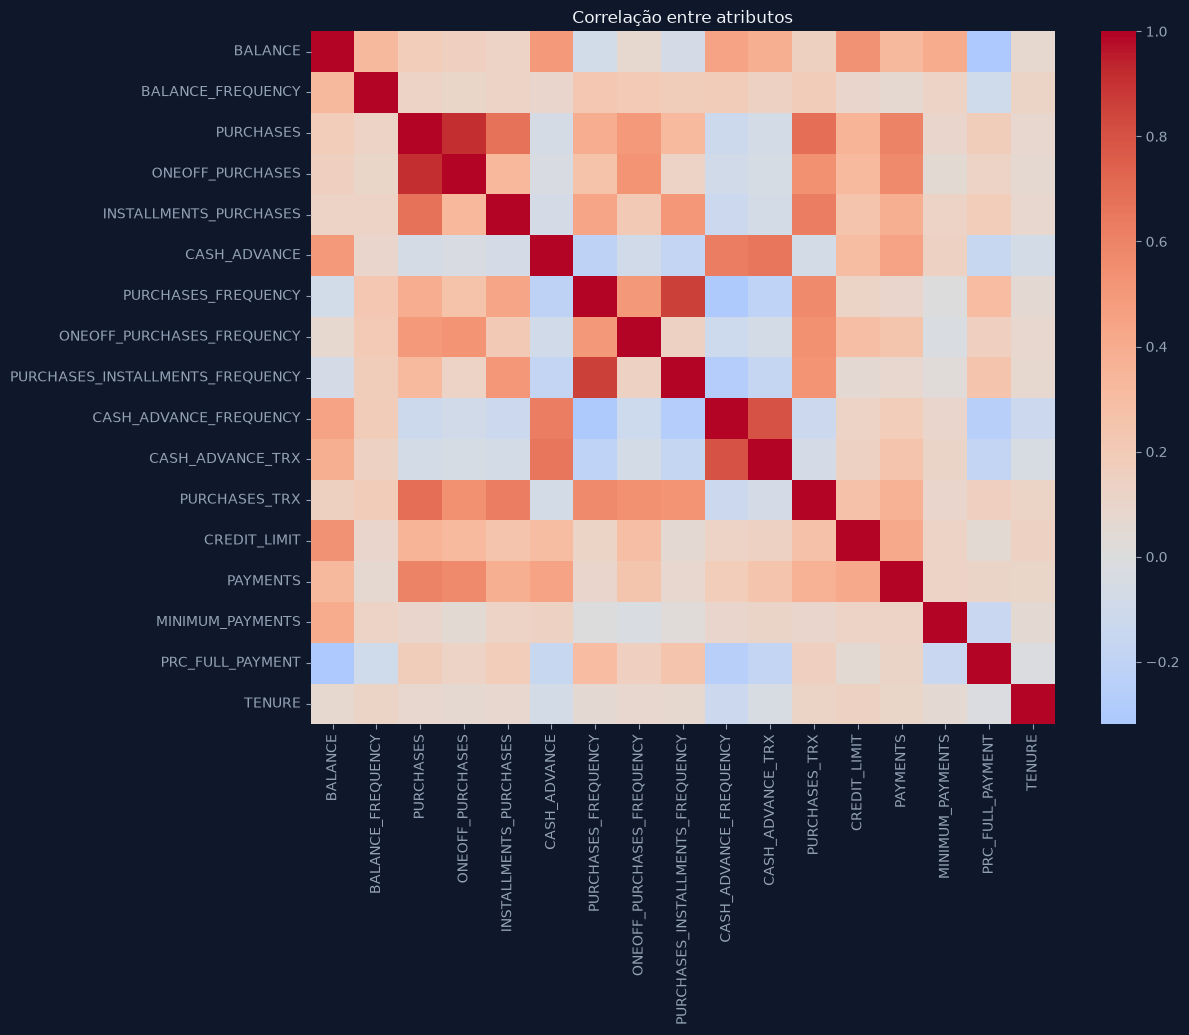

In [13]:
corr = df.drop(columns=['CUST_ID']).corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlação entre atributos')
plt.show()

> A leitura visual mostra todos os pares, funciona mas um farei limiar com pares acima de `0,6` para não depender de inspeção visual.

In [14]:
corr_pares = corr.unstack()
corr_pares[(corr_pares > .6) & (corr_pares < 1)]

PURCHASES                         ONEOFF_PURCHASES                    0.916845
                                  INSTALLMENTS_PURCHASES              0.679896
                                  PURCHASES_TRX                       0.689561
                                  PAYMENTS                            0.603264
ONEOFF_PURCHASES                  PURCHASES                           0.916845
INSTALLMENTS_PURCHASES            PURCHASES                           0.679896
                                  PURCHASES_TRX                       0.628108
CASH_ADVANCE                      CASH_ADVANCE_FREQUENCY              0.628522
                                  CASH_ADVANCE_TRX                    0.656498
PURCHASES_FREQUENCY               PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
PURCHASES_INSTALLMENTS_FREQUENCY  PURCHASES_FREQUENCY                 0.862934
CASH_ADVANCE_FREQUENCY            CASH_ADVANCE                        0.628522
                                  CASH_ADVANCE_TRX  

> O filtro confirma e detalha dois grupos, o grupo de compra que se mostra reunindo `PURCHASES`, `ONEOFF_PURCHASES`, `INSTALLMENTS_PURCHASES`, `PURCHASES_TRX` e `PAYMENTS`, todos com correlação acima de 0,6 entre si. 
>
>  E o grupo de saque totalmente coeso, com `CASH_ADVANCE`, `CASH_ADVANCE_FREQUENCY` e `CASH_ADVANCE_TRX` correlacionados entre si em todos os pares. Essa visão sistemática reforça a leitura de que a base carrega dois blocos de atributos redundantes e comportamentalmente distintos, o que justifica ainda mais o uso de PCA para consolidar essa informação em poucos componentes.

### 3.3 Distribuições dos Atributos-Chave

Observo a distribuição dos atributos monetários mais relevantes para o comportamento de uso do cartão, antes de decidir a estratégia de padronização.

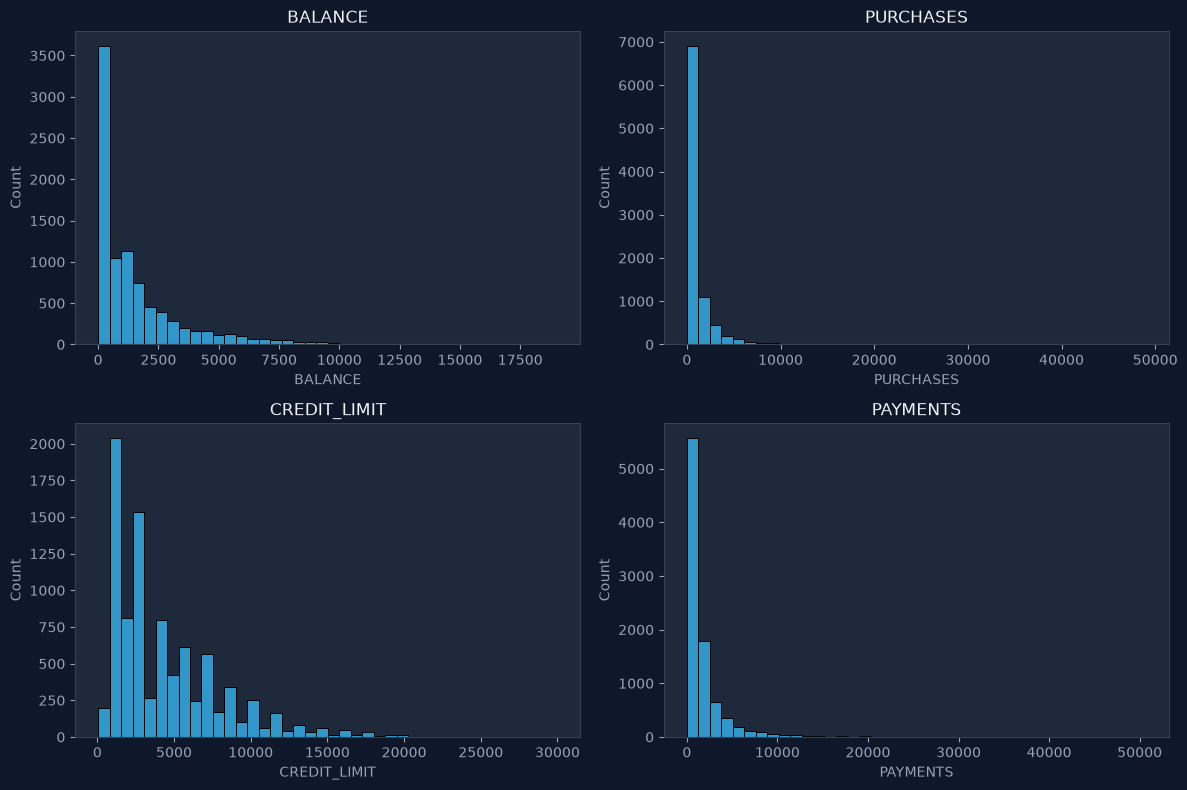

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, coluna in zip(axes.flat, ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS']):
    sns.histplot(df[coluna], ax=ax, bins=40, color='#38bdf8')
    ax.set_title(coluna)
plt.tight_layout()
plt.show()

> As três variáveis `BALANCE`, `PURCHASES` e `PAYMENTS` confirmam o padrão de assimetria positiva observado nas estatísticas descritivas. Sendo `PURCHASES` a mais extrema das três, o que já era esperado dado o padrão de mediana baixa visto anteriormente. `PAYMENTS` segue o mesmo formato.
>
>`CREDIT_LIMIT` se comporta de forma diferente. Em vez de um decaimento suave, a contagem oscila entre faixas, com picos recorrentes mostrando um padrão de dente de serra que sugere que os limites de crédito são concedidos em valores redondos e discretos, não distribuídos de forma contínua, provavelmente refletindo faixas de aprovação padronizadas pela operadora do cartão.

### 3.4 Resumo da Análise Exploratória

Os atributos `TENURE` e `CUST_ID` não trazem informação relevante para o agrupamento, o primeiro por baixa variância, o segundo por ser um identificador. Já os atributos monetários exigem padronização antes do K-Means, dada a assimetria de suas distribuições e a diferença de escala entre eles.

---

## 4. Tratamento e Limpeza dos Dados

### 4.1 Remoção de Atributos Não Informativos

In [20]:
print(f'Antes  : {df.shape[1]} Atributos')
df = df.drop(columns=['CUST_ID', 'TENURE'])
print(f'Depois : {df.shape[1]} Atributos')

Antes  : 18 Atributos
Depois : 16 Atributos


### 4.2 Tratamento de Valores Nulos

Preencho os valores ausentes com a mediana de cada atributo, opção mais robusta a outliers do que a média, o que é relevante dado que os atributos monetários apresentam cauda longa, como observado na análise exploratória.

In [21]:
print(f"Valores nulos antes  : {df.isna().sum().sum()}")
df = df.fillna(df.median())
print(f"Valores nulos depois : {df.isna().sum().sum()}")

Valores nulos antes  : 314
Valores nulos depois : 0


### 4.3 Resumo do Tratamento

| Etapa | Impacto |
|---|---|
| Remoção de atributos | 2 removidos (`CUST_ID`, `TENURE`), 16 restantes |
| Preenchimento de nulos | 314 valores preenchidos pela mediana, 0 nulos restantes |

---

## 5. Preparação para o Modelo

Como o K-Means se baseia em distância euclidiana, atributos em escalas diferentes (como `BALANCE`, que chega a dezenas de milhares, contra `BALANCE_FREQUENCY`, limitado entre zero e um) dominariam o cálculo se não forem padronizados. Utilizo o `StandardScaler`, que centraliza cada atributo em média zero e desvio padrão um, abordagem mais convencional para K-Means do que a normalização, já que preserva a escala relativa entre os próprios atributos em vez de forçar cada cliente a somar uma unidade de norma.

Não separo os dados em treino e teste aqui, já que a clusterização é aplicada ao conjunto completo. A divisão em subconjuntos aparece mais adiante, na etapa de avaliação, com outro propósito, verificar a estabilidade dos clusters encontrados.

In [22]:
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(df)
dados_padronizados

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.52897879,
        -0.3024    , -0.52555097],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.81864213,
         0.09749953,  0.2342269 ],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.38380474,
        -0.0932934 , -0.52555097],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.5706145 ,
        -0.32687479,  0.32919999],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.58053567,
        -0.33830497,  0.32919999],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.57686873,
        -0.3243581 , -0.52555097]], shape=(8950, 16))

---

## 6. Treinamento do Modelo

### 6.1 Escolha do Número de Clusters

Antes de treinar o modelo final, determino o número de clusters mais adequado observando como a inércia (soma das distâncias quadradas dentro de cada cluster) e o coeficiente de Silhouette se comportam ao longo de um intervalo de valores de k.

In [31]:
inercias = []
silhouettes = []
valores_k = range(2, 11)

for k in valores_k:
    kmeans_teste = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels_teste = kmeans_teste.fit_predict(dados_padronizados)
    inercias.append(kmeans_teste.inertia_)
    silhouettes.append(metrics.silhouette_score(dados_padronizados, labels_teste))

In [32]:
for i, v in enumerate(inercias):
    print(f'Clusters: {i+2} - Inercia:{v:.2f}')

Clusters: 2 - Inercia:118899.27
Clusters: 3 - Inercia:103156.43
Clusters: 4 - Inercia:90184.65
Clusters: 5 - Inercia:82709.79
Clusters: 6 - Inercia:76009.47
Clusters: 7 - Inercia:70910.51
Clusters: 8 - Inercia:67411.68
Clusters: 9 - Inercia:63125.45
Clusters: 10 - Inercia:59672.47


In [33]:
for i, v in enumerate(silhouettes):
    print(f'Clusters: {i+2} - silhouettes:{v:.2f}')

Clusters: 2 - silhouettes:0.23
Clusters: 3 - silhouettes:0.27
Clusters: 4 - silhouettes:0.22
Clusters: 5 - silhouettes:0.21
Clusters: 6 - silhouettes:0.22
Clusters: 7 - silhouettes:0.23
Clusters: 8 - silhouettes:0.22
Clusters: 9 - silhouettes:0.23
Clusters: 10 - silhouettes:0.23


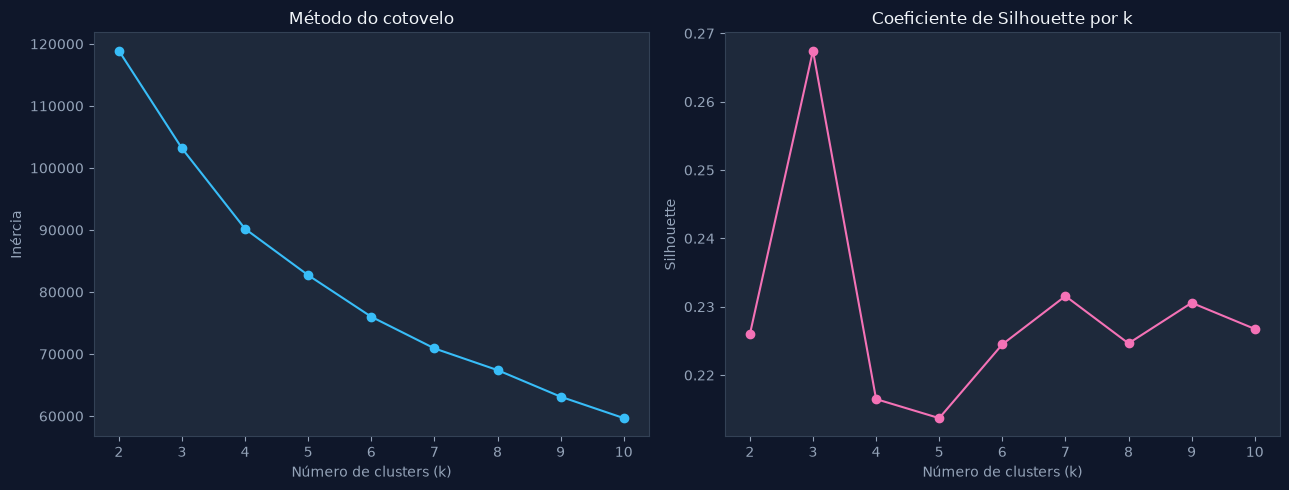

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(valores_k, inercias, marker='o', color='#38bdf8')
axes[0].set_title('Método do cotovelo')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inércia')

axes[1].plot(valores_k, silhouettes, marker='o', color='#f472b6')
axes[1].set_title('Coeficiente de Silhouette por k')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette')

plt.tight_layout()
plt.show()

> O coeficiente de Silhouette atinge seu valor mais alto em k=3 (0,2675), cai nos valores seguintes e volta a subir de forma discreta perto de k=7 (0,2316) e k=9 (0,2306), sem nunca superar o pico de k=3. Já a curva de inércia não apresenta um cotovelo nítido, a queda mais acentuada acontece entre k=2 e k=4, e depois desacelera de forma gradual, sem ponto de quebra óbvio, o que é comum em dados reais e menos limpo do que os exemplos didáticos costumam sugerir.
>
> Diante dessa ambiguidade na curva de cotovelo, uso o Silhouette como critério decisivo, por medir diretamente a separação entre os clusters, e escolho k=3. Esse valor também favorece a leitura de negócio, evitando fragmentar demais os perfis de cliente.

### 6.2 Treinamento do K-Means Final

In [36]:
N_CLUSTERS = 3

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
labels = kmeans.fit_predict(dados_padronizados)

df['cluster'] = labels
df.sample(5)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,cluster
328,850.630114,1.000000,0.05,0.05,0.00,1700.634586,0.083333,0.083333,0.000000,0.333333,7,1,1000.0,1084.281127,367.409536,0.0,1
4793,2032.338405,0.909091,158.24,0.00,158.24,2508.932178,0.666667,0.000000,0.583333,0.250000,5,8,2500.0,625.314406,632.198197,0.0,1
7514,254.947010,1.000000,2870.83,2655.15,215.68,0.000000,1.000000,0.818182,0.727273,0.000000,0,54,7500.0,2461.126057,194.290114,0.9,0
8907,2.559461,0.571429,116.10,0.00,116.10,0.000000,0.857143,0.000000,0.714286,0.000000,0,6,1500.0,256.642179,66.289561,0.5,1
3091,950.313080,1.000000,1022.84,1022.84,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,5,1500.0,818.113846,2083.026155,0.0,1


### 6.3 Interpretação dos Centroides

Trago os centroides de volta à escala original dos atributos para facilitar a leitura, já que em escala padronizada os valores não têm significado direto para alguém fora do contexto técnico.

In [37]:
kmeans.cluster_centers_

array([[ 0.30233304,  0.43856947,  1.52363197,  1.27913797,  1.25218953,
        -0.25229972,  1.14336955,  1.57003597,  0.94941716, -0.3649658 ,
        -0.25443572,  1.67263381,  0.88109055,  0.82937602,  0.15635565,
         0.50338512],
       [-0.36702129, -0.17984921, -0.23432345, -0.20566115, -0.17611612,
        -0.30727985, -0.06670206, -0.2388895 , -0.05064807, -0.33182567,
        -0.2973669 , -0.24528577, -0.33670924, -0.28452482, -0.13782303,
         0.00499702],
       [ 1.17551284,  0.34949892, -0.28738931, -0.20689838, -0.29949013,
         1.37840481, -0.63534783, -0.30602684, -0.54579623,  1.56067381,
         1.34195185, -0.36145833,  0.60751336,  0.4471824 ,  0.40802259,
        -0.41186217]])

In [38]:
centroides = scaler.inverse_transform(kmeans.cluster_centers_)
centroides

array([[2.19375554e+03, 9.81163785e-01, 4.25846803e+03, 2.71554441e+03,
        1.54340710e+03, 4.49786823e+02, 9.49240000e-01, 6.70829869e-01,
        7.41760002e-01, 6.21108187e-02, 1.51248993e+00, 5.62852538e+01,
        7.70008058e+03, 4.13410618e+03, 1.20963165e+03, 3.00946164e-01],
       [8.00551000e+02, 8.34666107e-01, 5.02569165e+02, 2.51081989e+02,
        2.51808025e+02, 3.34490918e+02, 4.63579788e-01, 1.31192313e-01,
        3.44308504e-01, 6.87424958e-02, 1.21951618e+00, 8.61294541e+00,
        3.26918496e+03, 9.09472378e+02, 5.23412222e+02, 1.55176192e-01],
       [4.01120557e+03, 9.60063792e-01, 3.89193143e+02, 2.49028441e+02,
        1.40242432e+02, 3.86945039e+03, 2.35354762e-01, 1.11163940e-01,
        1.47523960e-01, 4.47450960e-01, 1.24066625e+01, 5.72532998e+00,
        6.70468545e+03, 3.02769308e+03, 1.79668555e+03, 3.32520264e-02]])

In [39]:
df_centroides = pd.DataFrame(centroides, columns=df.columns[:-1])
df_centroides

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT
0,2193.755538,0.981164,4258.468026,2715.544408,1543.407099,449.786823,0.949240,0.670830,0.741760,0.062111,1.512490,56.285254,7700.080580,4134.106178,1209.631652,0.300946
1,800.551000,0.834666,502.569165,251.081989,251.808025,334.490918,0.463580,0.131192,0.344309,0.068742,1.219516,8.612945,3269.184960,909.472378,523.412222,0.155176
2,4011.205574,0.960064,389.193143,249.028441,140.242432,3869.450391,0.235355,0.111164,0.147524,0.447451,12.406662,5.725330,6704.685447,3027.693085,1796.685547,0.033252


> Os centroides revelam três perfis nitidamente diferentes. O cluster 0 se destaca por `PURCHASES` (4258,47) e `PURCHASES_FREQUENCY` (0,95) bem acima dos demais, além do maior `CREDIT_LIMIT` (7700,08) e maior `PRC_FULL_PAYMENT` (0,30), perfil de cliente que compra com frequência e paga a fatura em dia. 
>
>O cluster 2 se diferencia pelo lado oposto, `CASH_ADVANCE` (3869,45) e `CASH_ADVANCE_FREQUENCY` (0,45) muito acima dos outros clusters, com o menor `PRC_FULL_PAYMENT` (0,03), cliente que recorre ao saque e raramente quita a fatura integralmente.
>
> O cluster 1 fica com os valores mais baixos em praticamente todos os atributos monetários, reunindo os clientes de menor uso do cartão.

---

## 7. Avaliação do Modelo

Diferente de um modelo supervisionado, não há aqui métricas de erro para comparar com um valor verdadeiro. Uso três métricas específicas de validação de clusterização, cada uma sensível a um aspecto diferente da qualidade do agrupamento.

### 7.1 Métricas de Validação

- O coeficiente de Silhouette varia de -1 a 1, e quanto mais próximo de 1, melhor a separação entre clusters.
- O índice de Davies-Bouldin mede a razão entre dispersão interna e separação entre clusters, e quanto mais próximo de 0, melhor.
- O índice de Calinski-Harabasz considera a dispersão entre e dentro dos clusters, e quanto maior o valor, melhor. Diferente dos outros dois, não tem um limite fixo, então seu valor isolado não diz muita coisa, só faz sentido em comparação, o que faço a seguir.

In [40]:
silhouette = metrics.silhouette_score(dados_padronizados, labels, metric='euclidean')
davies_bouldin = metrics.davies_bouldin_score(dados_padronizados, labels)
calinski_harabasz = metrics.calinski_harabasz_score(dados_padronizados, labels)

print(f"Silhouette         : {silhouette:.4f}")
print(f"Davies-Bouldin     : {davies_bouldin:.4f}")
print(f"Calinski-Harabasz  : {calinski_harabasz:.4f}")

Silhouette         : 0.2675
Davies-Bouldin     : 1.5218
Calinski-Harabasz  : 1736.5365


> O Silhouette de 0,2675 indica separação positiva, porém moderada, entre os clusters, esperado dado que o comportamento de uso de cartão de crédito tende a formar grupos contínuos, sem fronteiras nítidas.
>
> O Davies-Bouldin de 1,5218 reflete alguma sobreposição entre os grupos.
>
> Já o Calinski-Harabasz de 1736,54 só terá significado quando comparado a uma referência.

### 7.2 Comparação com Dados Aleatórios

Para confirmar que a estrutura encontrada reflete um padrão real dos dados e não é um artefato do próprio algoritmo, que sempre retorna algum agrupamento independente de haver estrutura real, comparo as métricas obtidas com as mesmas métricas calculadas sobre dados aleatórios de mesma dimensão.

In [41]:
np.random.seed(42)
dados_aleatorios = np.random.rand(*dados_padronizados.shape)

kmeans_aleatorio = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
labels_aleatorios = kmeans_aleatorio.fit_predict(dados_aleatorios)

silhouette_aleatorio = metrics.silhouette_score(dados_aleatorios, labels_aleatorios)
davies_bouldin_aleatorio = metrics.davies_bouldin_score(dados_aleatorios, labels_aleatorios)
calinski_aleatorio = metrics.calinski_harabasz_score(dados_aleatorios, labels_aleatorios)

print(f"Silhouette (aleatório)        : {silhouette_aleatorio:.4f}")
print(f"Davies-Bouldin (aleatório)    : {davies_bouldin_aleatorio:.4f}")
print(f"Calinski-Harabasz (aleatório) : {calinski_aleatorio:.4f}")

Silhouette (aleatório)        : 0.0400
Davies-Bouldin (aleatório)    : 3.9933
Calinski-Harabasz (aleatório) : 375.8097


> Contra dados aleatórios de mesma dimensão, as três métricas confirmam que a estrutura encontrada é real. O Silhouette dos dados reais é quase 6,7 vezes maior que o dos dados aleatórios (0,2675 contra 0,0400).
>
> O Davies-Bouldin caiu para menos da metade (1,5218 contra 3,9933, lembrando que menor é melhor).
>
> E o Calinski-Harabasz é 4,6 vezes maior (1736,54 contra 375,81).
>
> Esse contraste descarta a hipótese de que o agrupamento é apenas um artefato do algoritmo, o K-Means sempre retorna algum resultado, mas aqui há evidência clara de estrutura genuína nos dados.

### 7.3 Estabilidade dos Clusters

Divido a base em três subconjuntos aleatórios e repito a clusterização em cada um. A lógica é: se as métricas se mantiverem próximas entre os subconjuntos, tenho um indício de que o agrupamento é estável e não depende de particularidades de uma amostra específica.

In [48]:
dados_embaralhados = dados_padronizados.copy()
np.random.seed(42)
indices = np.random.permutation(len(dados_embaralhados))
subconjuntos = np.array_split(dados_embaralhados[indices], 3)

for i, subconjunto in enumerate(subconjuntos, start=1):
    kmeans_sub = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
    labels_sub = kmeans_sub.fit_predict(subconjunto)
    s = metrics.silhouette_score(subconjunto, labels_sub)
    dbs = metrics.davies_bouldin_score(subconjunto, labels_sub)
    ch = metrics.calinski_harabasz_score(subconjunto, labels_sub)
    print(f"Subconjunto {i}: silhouette={s:.4f}, davies_bouldin={dbs:.4f}, calinski={ch:.4f}")

Subconjunto 1: silhouette=0.2083, davies_bouldin=1.6467, calinski=597.1261
Subconjunto 2: silhouette=0.2646, davies_bouldin=1.5390, calinski=580.9914
Subconjunto 3: silhouette=0.2339, davies_bouldin=1.5366, calinski=592.8484


> As métricas se mantiveram próximas entre os três subconjuntos, Silhouette entre 0,2083 e 0,2646, Davies-Bouldin entre 1,5366 e 1,6467, e Calinski-Harabasz entre 580,99 e 597,13, essa última com pouca variação entre o menor e o maior valor.
>
> É esperado que o Calinski-Harabasz dos subconjuntos seja bem menor que o valor obtido com a base completa (1736,54), já que esse índice cresce com o tamanho da amostra, o que interessa aqui é a consistência entre os três subconjuntos, não a comparação com o valor da base inteira. Essa proximidade indica que o agrupamento não depende de particularidades de uma amostra específica, é um resultado estável mesmo quando a base é dividida aleatoriamente.

---

## 8. Interpretação dos Clusters

### 8.1 Visualização com PCA

Com 16 atributos, não é possível visualizar os clusters diretamente. Uso PCA para reduzir os dados a dois componentes principais, o que permite uma visualização aproximada da separação entre os grupos, superando a limitação de um gráfico de dispersão simples entre apenas dois atributos originais.

In [49]:
pca = PCA(n_components=2, random_state=42)
componentes = pca.fit_transform(dados_padronizados)

print(f"Variância explicada pelos 2 componentes: {pca.explained_variance_ratio_.sum():.2%}")

Variância explicada pelos 2 componentes: 50.44%


> Os dois componentes principais explicam 50,44% da variância total. Isso significa que aproximadamente metade da informação original se perde nessa projeção, então a leitura do gráfico a seguir deve ser vista como uma aproximação, não como retrato fiel da separação real entre os clusters nas 16 dimensões originais.

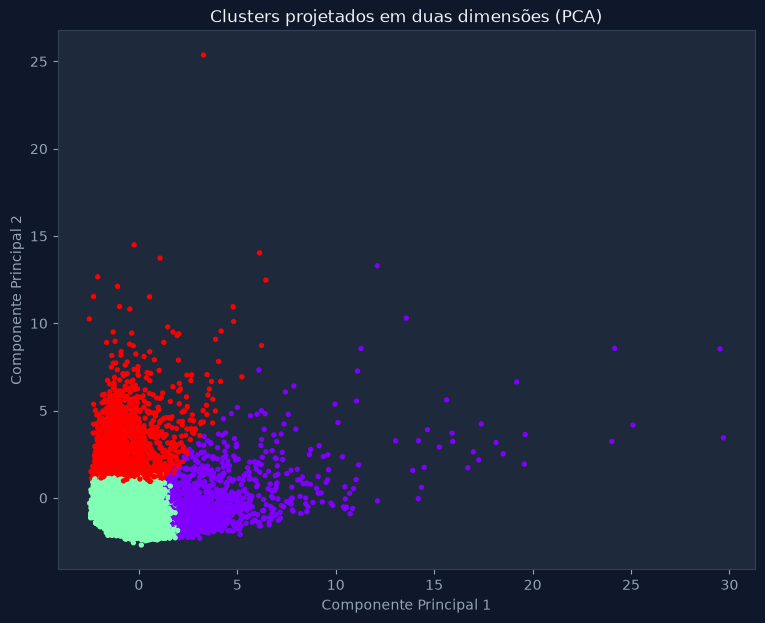

In [50]:
plt.figure(figsize=(9, 7))
plt.scatter(componentes[:, 0], componentes[:, 1], c=labels, cmap='rainbow', s=8)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.title('Clusters projetados em duas dimensões (PCA)')
plt.show()

> A separação entre os clusters é perceptível, mas com sobreposição relevante próxima à origem do gráfico. O cluster mais numeroso ocupa uma faixa mais compacta e central, enquanto os outros dois se espalham em direções distintas a partir dessa região, um se estendendo mais para valores negativos do primeiro componente, outro para valores mais positivos.
>
> Essa sobreposição parcial é esperada, já que a projeção descarta quase metade da variância original, e é coerente com o Silhouette moderado (0,2675) já calculado.

### 8.2 Perfil Estatístico por Cluster

Observo a média dos atributos mais relevantes para caracterizar o comportamento de cada cluster.

In [51]:
df.groupby('cluster')[['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT']].mean().round(2)

,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT
cluster,,,,,,
0,2193.76,4258.47,449.79,7700.08,4134.11,0.30
1,800.39,502.64,334.15,3269.31,909.22,0.16
2,4009.82,388.97,3868.52,6702.04,3027.34,0.03


> O cluster 0 concentra os maiores valores de `PURCHASES` (4258,47) e `PAYMENTS` (4134,11), com `CASH_ADVANCE` baixo (449,79) e o maior `PRC_FULL_PAYMENT` (0,30), perfil de cliente que compra bastante e paga bem.
>
> O cluster 1 tem os menores valores em quase todos os atributos, `BALANCE` (800,39), `PURCHASES` (502,64) e `PAYMENTS` (909,22), reunindo os clientes de baixo uso do cartão.
>
> O cluster 2 se destaca pelo `CASH_ADVANCE` muito acima dos demais (3868,52) e pelo menor `PRC_FULL_PAYMENT` (0,03), indicando clientes que recorrem ao saque e raramente quitam a fatura integralmente, apesar de terem o `BALANCE` mais alto dos três (4009,82).

### 8.3 Tamanho dos Clusters

In [52]:
df['cluster'].value_counts().sort_index()

cluster
0    1241
1    6117
2    1592
Name: count, dtype: int64

In [53]:
df['cluster'].value_counts(normalize=True).sort_index()

cluster
0    0.138659
1    0.683464
2    0.177877
Name: proportion, dtype: float64

> O cluster 1 concentra a maior parte da base, 6117 clientes (68,3%), o cluster 2 tem 1592 clientes (17,8%), e o cluster 0 é o menor, com 1241 clientes (13,9%).
>
> A maioria dos clientes, portanto, tem uso baixo do cartão, enquanto os perfis de alto gasto por compra (cluster 0) e alto uso de saque (cluster 2) juntos representam menos de um terço da base.

### 8.4 Síntese dos Perfis

Com base no perfil estatístico (8.2) e no tamanho de cada grupo (8.3), nomeio os três clusters:

| Cluster | Tamanho | Nome | Característica central |
|---|---|---|---|
| 0 | 1241 (13,9%) | Compradores Engajados | Maior frequência e volume de compras, melhor taxa de quitação integral |
| 1 | 6117 (68,3%) | Uso Ocasional | Valores baixos em quase todos os atributos, maioria da base |
| 2 | 1592 (17,8%) | Dependentes de Saque | Uso intenso de saque, menor taxa de quitação integral |

O cluster Compradores Engajados e o cluster Dependentes de Saque confirmam, em dados reais de cluster, a separação comportamental já sugerida pela correlação da seção 3.2, um grupo orientado a compras, outro orientado a saque, com pouca sobreposição entre os dois. O cluster Uso Ocasional, maior grupo da base, reúne clientes de baixo engajamento com o cartão em geral, sem se encaixar claramente em nenhum dos dois extremos.

## 9. Conclusão e Considerações Finais

### 9.1 Síntese do Projeto

Apliquei o algoritmo K-Means para segmentar clientes de cartão de crédito a partir do padrão de uso, sem qualquer rótulo prévio. Antes do treinamento, defini o número de clusters por meio do método do cotovelo combinado ao coeficiente de Silhouette, e validei o resultado final com três métricas de clusterização, comparação contra dados aleatórios e teste de estabilidade em subconjuntos. Para interpretar os grupos encontrados, utilizei PCA para visualização em duas dimensões e o perfil estatístico de cada cluster.

| Métrica | Valor |
|---|---|
| Número de clusters (k) | 3 |
| Silhouette | 0,2675 |
| Davies-Bouldin | 1,5218 |
| Calinski-Harabasz | 1736,54 |
| Variância explicada pelo PCA (2D) | 50,44% |
| Total de clientes analisados | 8950 |

### 9.2 Achados Relevantes

A varredura sistemática de k (seção 6.1) apontou k=3 pelo Silhouette, diferente do k=5 usado como referência no curso original, e esse valor se mostrou compatível com os clusters finais, resultando em grupos claramente interpretáveis e sem fragmentação excessiva.

O achado mais consistente do projeto foi a separação entre comportamento de compra e comportamento de saque. Ela apareceu primeiro na correlação quase nula entre `CASH_ADVANCE` e `PURCHASES` (seção 3.2), e se confirmou nos clusters finais, o cluster Compradores Engajados concentra alto volume de compras e baixo uso de saque, o cluster Dependentes de Saque é o oposto. Ver essa mesma estrutura emergir de duas análises independentes, correlação bruta e clusterização, reforça que não é coincidência.

A comparação contra dados aleatórios (seção 7.2) também merece destaque, o Silhouette dos dados reais foi quase 6,7 vezes maior que o dos dados aleatórios, evidência direta de que a estrutura encontrada não é um artefato do algoritmo.

### 9.3 Limitações e Considerações

Este projeto não conta com rótulos verdadeiros para validar objetivamente a qualidade da segmentação, o que é uma limitação inerente a qualquer problema de aprendizado não supervisionado. A padronização por `StandardScaler` é sensível a outliers, e os atributos monetários desta base apresentam cauda longa, o que pode distorcer a posição dos centroides. A visualização por PCA em duas dimensões é uma aproximação que descarta parte da variância dos dados originais, podendo ocultar sobreposições reais entre clusters. O dataset também representa um recorte específico de clientes e período, sem garantia de que os perfis encontrados se generalizem para outras bases de cartão de crédito. Este projeto tem finalidade educacional e de composição de portfólio.

---

## 10. Referências

* Curso [Clustering: Extraindo Padrões de Dados](https://www.alura.com.br/conteudo/cluster-analysis), Alura, instrutora Thainá Mariani.
* Dataset [Credit Card Dataset for Clustering](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata), Kaggle.
* Documentação do [scikit-learn: sklearn.cluster.KMeans](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html).
* Documentação do [scikit-learn: métricas de clusterização](https://scikit-learn.org/stable/modules/clustering.html#clustering-performance-evaluation).

> Material desenvolvido para estudos e composição de portfólio a partir do curso
> [Clustering: Extraindo Padrões de Dados](https://www.alura.com.br/conteudo/cluster-analysis), para o repositório
> [data-trivium](https://github.com/esscova/data-trivium);
> com auxílio do Claude Anthropic para revisões e estruturação.